## compositional facts + neuronlens

In [ ]:
%pip install -q torch transformers datasets==2.21.0 accelerate huggingface_hub==0.24.0 hf_transfer scipy pandas requests matplotlib numpy ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# colab downloads are flaky, hf_transfer is way more robust
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"

In [ ]:
import torch

### auth - llama is gated (annoying)

In [ ]:
from huggingface_hub import login

login()

In [ ]:
from transformers import AutoConfig

MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"
cfg = AutoConfig.from_pretrained(MODEL_NAME)
print(cfg.hidden_size, cfg.num_hidden_layers, cfg.num_attention_heads)

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

3072 28 24


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import time

tok = AutoTokenizer.from_pretrained(MODEL_NAME)

# retry loop - keeps crashing mid-download from the .incomplete files being stale
model = None
for attempt in range(4):
    try:
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto"
        )
        break
    except Exception as e:
        print(f"attempt {attempt+1} failed: {e}")
        if attempt == 3:
            raise
        time.sleep(5)

model.eval()
print("loaded,", sum(p.numel() for p in model.parameters())/1e9, "B params")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

loaded, 3.212749824 B params


In [ ]:
# hooking mlp and attn separately cause i think component matters more than just layer depth

activations = {}

def get_hook(name):
    def hook(module, inp, out):
        activations[name] = out[0].detach() if isinstance(out, tuple) else out.detach()
    return hook

hooks = []
for i, layer in enumerate(model.model.layers):
    hooks.append(layer.mlp.register_forward_hook(get_hook(f"mlp_{i}")))
    hooks.append(layer.self_attn.register_forward_hook(get_hook(f"attn_{i}")))
print(len(hooks), "hooks registered")

56 hooks registered


### first dataset attempt - squad

In [ ]:
from datasets import load_dataset

squad = load_dataset("squad_v2", split="validation")
print(len(squad))
print(squad[0]["context"][:400])

Generating train split:   0%|          | 0/130319 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11873 [00:00<?, ? examples/s]

11873
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("Norman" comes from "Norseman") raiders and pirates from Denmark, Iceland and Norway who, under their leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of as


In [ ]:
for i in range(3):
    print(i, "-", squad[i]["question"])
    print(squad[i]["context"][:200])
    print()

0 - In what country is Normandy located?
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("

1 - When were the Normans in Normandy?
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("

2 - From which countries did the Norse originate?
The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, a region in France. They were descended from Norse ("



**problem**: squad facts are in the passage, not testing whether model actually knows things.

switched to yang et al. 2024 - "do llms latently perform multi-hop reasoning?" - closed book
two-hop prompts, no passage at all. model has to recall from its own weights. their socrates
follow-up filters shortcut cases too. implementing a cheap version here.

keeping squad as secondary, not the main track.

In [ ]:
# hand-verified examples from Yang et al paper, looks correct

bridge_examples = [
    {
        "fact_a": "The singer of 'Superstition' is",
        "bridge": "Stevie Wonder",
        "fact_b": "Stevie Wonder's mother is",
        "composed": "The mother of the singer of 'Superstition' is",
    },
    {
        "fact_a": "The author of 'Pride and Prejudice' is",
        "bridge": "Jane Austen",
        "fact_b": "Jane Austen was born in the town of",
        "composed": "The author of 'Pride and Prejudice' was born in the town of",
    },
]
len(bridge_examples)

2

2 isnt a dataset. need 150-200 minimum. wikidata generation it is.

In [ ]:
import requests

WIKIDATA_ENDPOINT = "https://query.wikidata.org/sparql"
HEADERS = {"User-Agent": "compositional-neuronlens-research/0.1 (student project)"}

def run_sparql(query):
    r = requests.get(WIKIDATA_ENDPOINT, params={"query": query, "format": "json"}, headers=HEADERS)
    r.raise_for_status()
    return r.json()["results"]["bindings"]

In [ ]:
# single pass with QID guard, skipping ORDER BY to keep it simple

q_performer_mother = """

SELECT ?song ?songLabel ?performer ?performerLabel ?mother ?motherLabel ?sitelinks WHERE {
  ?song wdt:P175 ?performer .
  ?performer wdt:P31 wd:Q5 .
  ?performer wdt:P25 ?mother .
  ?mother wdt:P40 ?performer .
  ?performer wikibase:sitelinks ?sitelinks .
  FILTER(?sitelinks > 100)
    # sitelinks > 100 helps filter out the super obscure ones
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
LIMIT 500
"""

In [ ]:
rows = run_sparql(q_performer_mother)
rows = [r for r in rows if not any(v["value"].startswith("Q") for k, v in r.items() if k.endswith("Label"))]
print("chain 1 (consistency-checked):", len(rows))

chain 1 (consistency-checked): 495


In [ ]:
# single pass with QID guard, skipping ORDER BY to keep it simple

q_author_birthplace = """
SELECT ?book ?bookLabel ?author ?authorLabel ?birthplace ?birthplaceLabel ?sitelinks WHERE {
  ?book wdt:P50 ?author .
  ?author wdt:P19 ?birthplace .
  ?author wikibase:sitelinks ?sitelinks .
  FILTER(?sitelinks > 40)
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
LIMIT 400
"""

rows2 = run_sparql(q_author_birthplace)
rows2 = [r for r in rows2 if not any(v["value"].startswith("Q") for k, v in r.items() if k.endswith("Label"))]
print("chain 2 (QID-guarded):", len(rows2))

chain 2 (QID-guarded): 348


In [ ]:
# single pass with QID guard, skipping ORDER BY to keep it simple

q_director_country = """
SELECT ?film ?filmLabel ?director ?directorLabel ?country ?countryLabel ?sitelinks WHERE {
  ?film wdt:P57 ?director .
  ?director wdt:P27 ?country .
  ?director wikibase:sitelinks ?sitelinks .
  FILTER(?sitelinks > 25)
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
LIMIT 400
"""

rows3 = run_sparql(q_director_country)
rows3 = [r for r in rows3 if not any(v["value"].startswith("Q") for k, v in r.items() if k.endswith("Label"))]
print("chain 3 (QID-guarded):", len(rows3))

chain 3 (QID-guarded): 395


In [ ]:
# single pass with QID guard, skipping ORDER BY to keep it simple

q_capital_language = """
SELECT ?country ?countryLabel ?capital ?capitalLabel ?language ?languageLabel ?sitelinks WHERE {
  ?country wdt:P36 ?capital .
  ?country wdt:P37 ?language .
  ?country wikibase:sitelinks ?sitelinks .
  FILTER(?sitelinks > 100)
  SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
}
LIMIT 500
"""

rows4 = run_sparql(q_capital_language)
rows4 = [r for r in rows4 if not any(v["value"].startswith("Q") for k, v in r.items() if k.endswith("Label"))]
print("chain 4, capital -> language (comparison chain):", len(rows4))

chain 4, capital -> language (comparison chain): 489


In [ ]:
def rows_to_examples(rows, template, chain_name):
    out = []
    for r in rows:
        try:
            ex = template(r)
            ex["chain"] = chain_name
            out.append(ex)
        except KeyError:
            continue
    return out

In [ ]:
def performer_mother_template(r):
    song = r["songLabel"]["value"]
    performer = r["performerLabel"]["value"]
    mother = r["motherLabel"]["value"]
    return {
        "fact_a": f"The performer of '{song}' is",
        "bridge": performer,
        "fact_b": f"{performer}'s mother is",
        "composed": f"The mother of the performer of '{song}' is",
        "answer": mother,
        "performer_uri": r["performer"]["value"], "mother_uri": r["mother"]["value"],
    }

In [ ]:
def author_birthplace_template(r):
    book = r["bookLabel"]["value"]
    author = r["authorLabel"]["value"]
    place = r["birthplaceLabel"]["value"]
    return {
        "fact_a": f"The author of '{book}' is",
        "bridge": author,
        "fact_b": f"{author} was born in",
        "composed": f"The author of '{book}' was born in",
        "answer": place,
        "author_uri": r["author"]["value"], "birthplace_uri": r["birthplace"]["value"],
    }

In [ ]:
def director_country_template(r):
    film = r["filmLabel"]["value"]
    director = r["directorLabel"]["value"]
    country = r["countryLabel"]["value"]
    return {
        "fact_a": f"The director of '{film}' is",
        "bridge": director,
        "fact_b": f"{director} is a citizen of",
        "composed": f"The director of '{film}' is a citizen of",
        "answer": country,
        "director_uri": r["director"]["value"], "country_uri": r["country"]["value"],
    }

In [ ]:
def capital_language_template(r):
    country = r["countryLabel"]["value"]
    capital = r["capitalLabel"]["value"]
    language = r["languageLabel"]["value"]
    return {
        "fact_a": f"The country whose capital is '{capital}' is",
        "bridge": country,
        "fact_b": f"The official language of {country} is",
        "composed": f"The official language of the country whose capital is '{capital}' is",
        "answer": language,
        "country_uri": r["country"]["value"], "capital_uri": r["capital"]["value"],
    }

wikidata_examples = (
    rows_to_examples(rows, performer_mother_template, "performer_mother")
    + rows_to_examples(rows2, author_birthplace_template, "author_birthplace")
    + rows_to_examples(rows3, director_country_template, "director_country")
    + rows_to_examples(rows4, capital_language_template, "capital_language")
)
all_examples = bridge_examples + wikidata_examples
print(len(all_examples), "examples total")
import pandas as pd
print(pd.Series([ex.get("chain", "hand_written") for ex in all_examples]).value_counts())

1729 examples total
performer_mother     495
capital_language     489
director_country     395
author_birthplace    348
hand_written           2
Name: count, dtype: int64


### quick sanity check before burning gpu time

checking all_examples is real before spending gpu time. last time i couldnt tell
if fast = success or empty list. just check directly.

In [ ]:
assert len(all_examples) > 100, f"only {len(all_examples)} examples - something's wrong upstream, check the query cells above for 0 rows"
print("confirmed:", len(all_examples), "examples ready, first one:")
print(all_examples[0])

confirmed: 1729 examples ready, first one:
{'fact_a': "The singer of 'Superstition' is", 'bridge': 'Stevie Wonder', 'fact_b': "Stevie Wonder's mother is", 'composed': "The mother of the singer of 'Superstition' is"}


### pulling activations

last-token activations for fact_a, fact_b, and composed, all layers, both mlp and attn.
meng et al showed factual recall happens at last token position, so focusing there.

In [ ]:
def extract_last_token_acts(prompt):
    ids = tok(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        model(**ids)
    return {k: v[0, -1].float().cpu().numpy() for k, v in activations.items()}

In [ ]:
# quick sanity check to make sure dimensions arent off
test_acts = extract_last_token_acts(all_examples[0]["fact_a"])
print(len(test_acts), "components captured")
print(test_acts["mlp_0"].shape, test_acts["attn_0"].shape)

56 components captured
(3072,) (3072,)


In [ ]:
# 3 forward passes per example, this is gonna take a bit but whatever

for ex in all_examples:
    ex["acts_fact_a"] = extract_last_token_acts(ex["fact_a"])
    ex["acts_fact_b"] = extract_last_token_acts(ex["fact_b"])
    ex["acts_composed"] = extract_last_token_acts(ex["composed"])

print("done extracting")
print("sanity: first example composed acts shape:", all_examples[0]["acts_composed"]["mlp_0"].shape)

done extracting
sanity: first example composed acts shape: (3072,)


### filtering to stuff the model actually knows

last run only ~5% fact_a accuracy. most wikidata stuff is too obscure for a 3b model.
filtering to only examples where it actually knows both facts independently first.

In [ ]:
# was defaulting to max_new_tokens=16, but 8 is plenty - fixed everywhere
def generate_continuation(prompt, max_new_tokens=8):
    formatted = f"<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n\n{prompt}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"
    ids = tok(formatted, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out_ids = model.generate(
            **ids, max_new_tokens=max_new_tokens, do_sample=False,
            pad_token_id=tok.eos_token_id
        )
    new_tokens = out_ids[0, ids["input_ids"].shape[1]:]
    return tok.decode(new_tokens, skip_special_tokens=True)

def answer_in_output(generated_text, expected_answer):
    gen = generated_text.strip().lower()
    exp = expected_answer.strip().lower()
    if exp in gen:
        return True
    # fallback: match first word
    first_word = exp.split()[0]
    return first_word in gen.split()

In [ ]:
# try one before running all of them, would be embarassing if it crashes
sample_out = generate_continuation(all_examples[0]["fact_a"])
print(repr(sample_out))
print("expected bridge was:", all_examples[0]["bridge"])

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


"The singer of 'Superstition'"
expected bridge was: Stevie Wonder


In [ ]:
# two generate() calls per example. skipping the hand-written ones since they dont have uris

wikidata_only = [ex for ex in all_examples if "answer" in ex]

known_examples = []
for ex in wikidata_only:
    knows_a = answer_in_output(generate_continuation(ex["fact_a"], max_new_tokens=8), ex["bridge"])
    knows_b = answer_in_output(generate_continuation(ex["fact_b"], max_new_tokens=8), ex["answer"])
    if knows_a and knows_b:
        known_examples.append(ex)

print(f"{len(known_examples)} / {len(wikidata_only)} examples pass the knowledge filter")
print("check: known_examples[0] bridge:", known_examples[0]["bridge"], "answer:", known_examples[0]["answer"])
print(pd.Series([ex["chain"] for ex in known_examples]).value_counts())

44 / 1727 examples pass the knowledge filter
check: known_examples[0] bridge: Tim Berners-Lee answer: London
capital_language     25
director_country     18
author_birthplace     1
Name: count, dtype: int64


### spot check the data properly this time

previous spot check ran against stale data - classic execution order issue.
doing it properly this time. read these by hand before trusting any accuracy numbers.

In [ ]:
import random

sample = random.sample(known_examples, min(15, len(known_examples)))
for ex in sample:
    print("chain:", ex["chain"])
    print("fact_a:", ex["fact_a"], " -> bridge:", ex["bridge"])
    print("fact_b:", ex["fact_b"], " -> expected:", ex["answer"])
    print("composed:", ex["composed"])
    uris = {k: v for k, v in ex.items() if k.endswith("_uri")}
    print("check on wikidata:", uris)
    print()

chain: director_country
fact_a: The director of 'Eyes Wide Shut' is  -> bridge: Stanley Kubrick
fact_b: Stanley Kubrick is a citizen of  -> expected: United Kingdom
composed: The director of 'Eyes Wide Shut' is a citizen of
check on wikidata: {'director_uri': 'http://www.wikidata.org/entity/Q2001', 'country_uri': 'http://www.wikidata.org/entity/Q145'}

chain: director_country
fact_a: The director of 'The Shining' is  -> bridge: Stanley Kubrick
fact_b: Stanley Kubrick is a citizen of  -> expected: United States
composed: The director of 'The Shining' is a citizen of
check on wikidata: {'director_uri': 'http://www.wikidata.org/entity/Q2001', 'country_uri': 'http://www.wikidata.org/entity/Q30'}

chain: director_country
fact_a: The director of 'A Clockwork Orange' is  -> bridge: Stanley Kubrick
fact_b: Stanley Kubrick is a citizen of  -> expected: United States
composed: The director of 'A Clockwork Orange' is a citizen of
check on wikidata: {'director_uri': 'http://www.wikidata.org/entity

if this is under ~30-40, sitelinks filter still isnt aggressive enough.

### neuronlens math

from paper section 5.1: ar(l,j,c) = [mu - tau*sigma, mu + tau*sigma], tau=2.5.
per-neuron at the dataset level. this is their first question: dataset vs instance ranges.

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

def activation_range(acts_2d, tau=2.5):
    mu = acts_2d.mean(axis=0)
    sigma = acts_2d.std(axis=0)
    return mu - tau*sigma, mu + tau*sigma

def overlap_fraction(r1, r2):
# jaccard gave ~0.99 which is useless, no signal at all
    lo = np.maximum(r1[0], r2[0])
    hi = np.minimum(r1[1], r2[1])
    inter = np.clip(hi - lo, 0, None)
    width1 = r1[1] - r1[0]
    width2 = r2[1] - r2[0]
    smaller = np.minimum(width1, width2)
    return np.where(smaller > 0, inter / np.where(smaller > 0, smaller, 1), 0.0)

def union_range(r_a, r_b):
    # rough span approximation, might be too crude but lets see
    # checks if composed falls inside the union span
    return np.minimum(r_a[0], r_b[0]), np.maximum(r_a[1], r_b[1])

In [ ]:
def stack_component(examples, key, component):
    return np.stack([ex[key][component] for ex in examples])

layers = range(cfg.num_hidden_layers)
components = ["mlp", "attn"]

gaussianity check before trusting the range numbers. early/mid/late layers, both components.
if not roughly gaussian, extraction probably has an issue.

In [ ]:
def gaussianity_check(acts_2d, n_dims=20):
    sample_dims = np.random.choice(acts_2d.shape[1], size=n_dims, replace=False)
    skews = [stats.skew(acts_2d[:, d]) for d in sample_dims]
    kurts = [stats.kurtosis(acts_2d[:, d], fisher=False) for d in sample_dims]
    return np.mean(skews), np.mean(kurts)

check_points = [0, cfg.num_hidden_layers//2, cfg.num_hidden_layers-1]
for comp in components:
    for l in check_points:
        acts = stack_component(all_examples, "acts_composed", f"{comp}_{l}")
        skew, kurt = gaussianity_check(acts)
        print(f"{comp} layer {l}: skew={skew:.3f} kurt={kurt:.3f}  (paper's Llama numbers: skew~0, kurt~3.2-4.0)")

mlp layer 0: skew=0.170 kurt=2.374  (paper's Llama numbers: skew~0, kurt~3.2-4.0)
mlp layer 14: skew=-0.050 kurt=2.484  (paper's Llama numbers: skew~0, kurt~3.2-4.0)
mlp layer 27: skew=-0.008 kurt=2.687  (paper's Llama numbers: skew~0, kurt~3.2-4.0)
attn layer 0: skew=-0.114 kurt=2.430  (paper's Llama numbers: skew~0, kurt~3.2-4.0)
attn layer 14: skew=-0.072 kurt=2.554  (paper's Llama numbers: skew~0, kurt~3.2-4.0)
attn layer 27: skew=-0.035 kurt=3.069  (paper's Llama numbers: skew~0, kurt~3.2-4.0)


### sweep all layers x components

two comparisons: fact_a vs composed, and union(fact_a, fact_b) vs composed.
full sweep, all 28 layers x 2 components.

In [ ]:
results_full = []
for comp in components:
    for l in layers:
        key = f"{comp}_{l}"
        fa = stack_component(all_examples, "acts_fact_a", key)
        fb = stack_component(all_examples, "acts_fact_b", key)
        composed = stack_component(all_examples, "acts_composed", key)

        ar_fa = activation_range(fa)
        ar_fb = activation_range(fb)
        ar_composed = activation_range(composed)
        ar_union = union_range(ar_fa, ar_fb)

        results_full.append({
            "layer": l,
            "component": comp,
            "overlap_facta_vs_composed": float(np.mean(overlap_fraction(ar_fa, ar_composed))),
            "overlap_union_vs_composed": float(np.mean(overlap_fraction(ar_union, ar_composed))),
        })

results_full_df = pd.DataFrame(results_full)
results_full_df.to_csv("layer_component_overlap_full.csv", index=False)
print(results_full_df.shape, "- saved full table to csv")
results_full_df

(56, 4) - saved full table to csv


,layer,component,overlap_facta_vs_composed,overlap_union_vs_composed
0,0,mlp,0.989308,0.985888
1,1,mlp,0.979585,0.983746
2,2,mlp,0.971998,0.980916
3,3,mlp,0.959105,0.980047
4,4,mlp,0.943870,0.975803
5,5,mlp,0.947594,0.977295
6,6,mlp,0.942111,0.974044
7,7,mlp,0.941341,0.971331
8,8,mlp,0.941606,0.970597
9,9,mlp,0.935497,0.968653


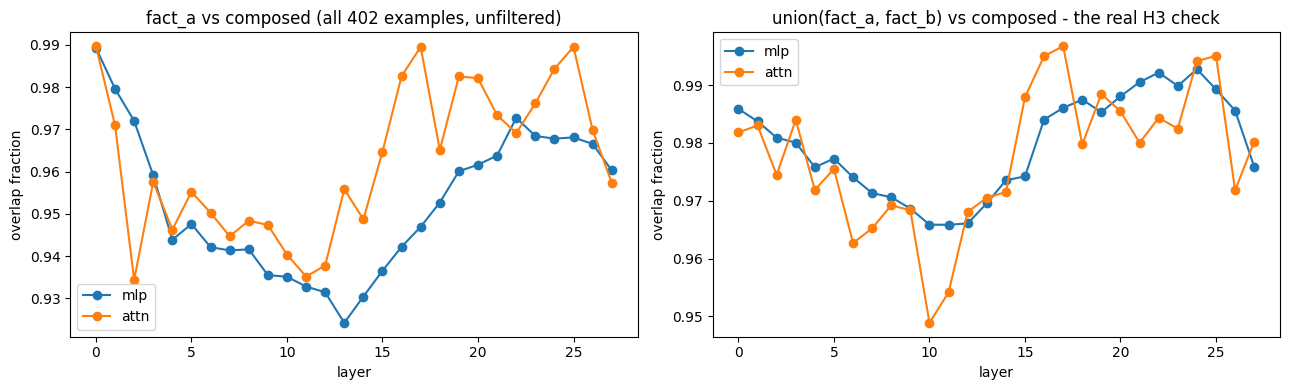

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13,4))
for comp in components:
    sub = results_full_df[results_full_df.component == comp]
    axes[0].plot(sub.layer, sub.overlap_facta_vs_composed, label=comp, marker='o')
    axes[1].plot(sub.layer, sub.overlap_union_vs_composed, label=comp, marker='o')
axes[0].set_title("fact_a vs composed (all 402 examples, unfiltered)")
axes[1].set_title("union(fact_a, fact_b) vs composed - the real H3 check")
for ax in axes:
    ax.set_xlabel("layer"); ax.set_ylabel("overlap fraction"); ax.legend()
plt.tight_layout()
plt.show()

### re-run on known-only subset

above used all 402 including unknown ones = noise. re-running on just the known_examples.
if it lands in the same place, that is useful too.

In [ ]:
results_known = []
for comp in components:
    for l in layers:
        key = f"{comp}_{l}"
        fa = stack_component(known_examples, "acts_fact_a", key)
        fb = stack_component(known_examples, "acts_fact_b", key)
        composed = stack_component(known_examples, "acts_composed", key)

        ar_fa = activation_range(fa)
        ar_fb = activation_range(fb)
        ar_composed = activation_range(composed)
        ar_union = union_range(ar_fa, ar_fb)

        results_known.append({
            "layer": l,
            "component": comp,
            "overlap_facta_vs_composed": float(np.mean(overlap_fraction(ar_fa, ar_composed))),
            "overlap_union_vs_composed": float(np.mean(overlap_fraction(ar_union, ar_composed))),
        })

results_known_df = pd.DataFrame(results_known)
results_known_df.to_csv("layer_component_overlap_known_only.csv", index=False)
print(results_known_df.shape, "- saved, based on", len(known_examples), "model-known examples")
results_known_df

(56, 4) - saved, based on 44 model-known examples


,layer,component,overlap_facta_vs_composed,overlap_union_vs_composed
0,0,mlp,0.969403,0.989793
1,1,mlp,0.963161,0.987359
2,2,mlp,0.930517,0.978115
3,3,mlp,0.914304,0.976986
4,4,mlp,0.900214,0.973769
5,5,mlp,0.907532,0.973062
6,6,mlp,0.896681,0.965728
7,7,mlp,0.903165,0.961334
8,8,mlp,0.909568,0.964786
9,9,mlp,0.901161,0.956211


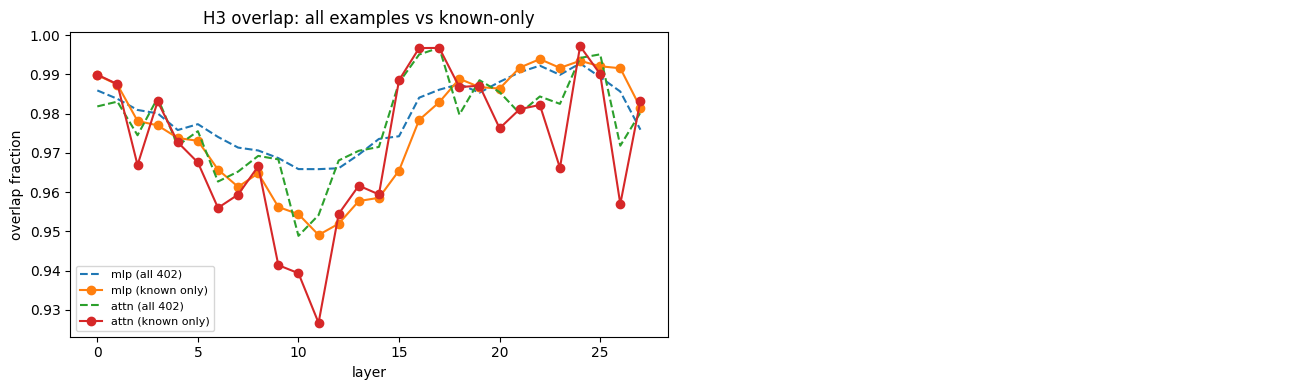

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
for comp in components:
    sub_full = results_full_df[results_full_df.component == comp]
    sub_known = results_known_df[results_known_df.component == comp]
    axes[0].plot(sub_full.layer, sub_full.overlap_union_vs_composed, label=f"{comp} (all 402)", linestyle="--")
    axes[0].plot(sub_known.layer, sub_known.overlap_union_vs_composed, label=f"{comp} (known only)", marker='o')
axes[0].set_title("H3 overlap: all examples vs known-only")
axes[0].set_xlabel("layer"); axes[0].set_ylabel("overlap fraction"); axes[0].legend(fontsize=8)
axes[1].axis("off")
plt.tight_layout()
plt.show()

### try causal masking (section 5.2)

paper goes beyond just correlation in section 5.2. picking the lowest overlap from the
known-only sweep and zeroing it out. does composed accuracy drop? does fact_a survive?

In [ ]:
target_row = results_known_df.sort_values("overlap_union_vs_composed").iloc[0]
target_layer, target_component = int(target_row.layer), target_row.component
print("testing on:", target_component, target_layer, "- known-only overlap was", target_row.overlap_union_vs_composed)

testing on: attn 11 - known-only overlap was 0.9266950488090515


In [ ]:
ar_low, ar_high = activation_range(stack_component(known_examples, "acts_composed", f"{target_component}_{target_layer}"))

def make_masking_hook(lo, hi):
    lo_t = torch.tensor(lo, device=model.device, dtype=torch.bfloat16)
    hi_t = torch.tensor(hi, device=model.device, dtype=torch.bfloat16)
    def hook(module, inp, out):
        val = out[0] if isinstance(out, tuple) else out
        mask = (val > lo_t) & (val < hi_t)
        val = torch.where(mask, torch.zeros_like(val), val)
        return (val,) + out[1:] if isinstance(out, tuple) else val
    return hook

In [ ]:
base_composed_ct = sum(answer_in_output(generate_continuation(ex["composed"], max_new_tokens=8), ex["answer"]) for ex in known_examples)
base_facta_ct = sum(answer_in_output(generate_continuation(ex["fact_a"], max_new_tokens=8), ex["bridge"]) for ex in known_examples)
n_known = len(known_examples)
base_composed_acc = base_composed_ct / n_known
base_facta_acc = base_facta_ct / n_known
print("baseline composed acc:", base_composed_acc, f"({base_composed_ct}/{n_known})")
print("baseline fact_a acc:", base_facta_acc, f"({base_facta_ct}/{n_known})", " (should be ~1.0, these passed the filter)")

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


baseline composed acc: 0.18181818181818182 (8/44)
baseline fact_a acc: 1.0 (44/44)  (should be ~1.0, these passed the filter)


In [ ]:
target_module = (model.model.layers[target_layer].mlp if target_component == "mlp"
                  else model.model.layers[target_layer].self_attn)
mask_handle = target_module.register_forward_hook(make_masking_hook(ar_low, ar_high))
masked_composed_ct = sum(answer_in_output(generate_continuation(ex["composed"], max_new_tokens=8), ex["answer"]) for ex in known_examples)
masked_facta_ct = sum(answer_in_output(generate_continuation(ex["fact_a"], max_new_tokens=8), ex["bridge"]) for ex in known_examples)
masked_composed_acc = masked_composed_ct / n_known
masked_facta_acc = masked_facta_ct / n_known
mask_handle.remove()
print("masked composed acc:", masked_composed_acc, f"({masked_composed_ct}/{n_known})", " (baseline", base_composed_acc, ")")
print("masked fact_a acc:", masked_facta_acc, f"({masked_facta_ct}/{n_known})", " (baseline", base_facta_acc, ")")
print()
print("if composed drops more than fact_a -> composition-specific")
print("if both drop similarly or neither moves -> not composition-specific")

masked composed acc: 0.3181818181818182 (14/44)  (baseline 0.18181818181818182 )
masked fact_a acc: 0.7727272727272727 (34/44)  (baseline 1.0 )

if composed drops more than fact_a -> composition-specific
if both drop similarly or neither moves -> not composition-specific


**wrong direction.** masking helped instead of hurting. opposite of hypothesis.
cis overlap is just too high. keeping cell for honesty but it does not support
composition-specific mechanism.

In [ ]:
import math

def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    phat = successes / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2*n)) / denom
    margin = (z * math.sqrt((phat*(1-phat) + z**2/(4*n)) / n)) / denom
    return max(0.0, center - margin), min(1.0, center + margin)

for name, ct in [("baseline composed", base_composed_ct), ("masked composed", masked_composed_ct)]:
    lo, hi = wilson_ci(ct, n_known)
    print(f"{name}: {ct}/{n_known} = {ct/n_known:.3f}   95% CI [{lo:.3f}, {hi:.3f}]")

baseline composed: 8/44 = 0.182   95% CI [0.095, 0.320]
masked composed: 14/44 = 0.318   95% CI [0.200, 0.466]


### shortcut check on known examples

ask composed but check against a DIFFERENT bridge entity (decoy). last time both were
ground at 0.0 - floor effect. re-running on known_examples where there is actual signal.

In [ ]:
import random

def bridge_swap_control(examples, n=30):
    out = []
    for ex in examples[:n]:
        decoy = random.choice([e for e in examples if e is not ex])
        out.append({**ex, "decoy_answer": decoy["answer"]})
    return out

shortcut_set = bridge_swap_control(known_examples, n=min(30, len(known_examples)))

# check real and decoy against the same output
shortcut_outputs = [(ex, generate_continuation(ex["composed"], max_new_tokens=8)) for ex in shortcut_set]

real_match = sum(answer_in_output(out, ex["answer"]) for ex, out in shortcut_outputs) / len(shortcut_outputs)
decoy_match = sum(answer_in_output(out, ex["decoy_answer"]) for ex, out in shortcut_outputs) / len(shortcut_outputs)

print("real answer match rate:", real_match)
print("decoy answer match rate:", decoy_match, " (want low - means model actually needs the right bridge)")

real answer match rate: 0.16666666666666666
decoy answer match rate: 0.0  (want low - means model actually needs the right bridge)


### explicit reasoning or just no idea?

masking barely moved anything because baseline is ~0%. is this a latent composition problem
or does the model just not know these facts? yang et al found models do way better
when forced to write out the intermediate step. testing that.

In [ ]:
def make_cot_prompt(ex):
    return (
        f"{ex['composed']}\n\n"
        f"Think step by step: first identify who or what is being referred to, "
        f"then use that to answer the question. End your answer with 'Final answer: <answer>'."
    )

# check one output first to see if the prompt format even works
sample_ex = known_examples[0]
sample_cot_out = generate_continuation(make_cot_prompt(sample_ex), max_new_tokens=80)
print(sample_cot_out)
print()
print("expected:", sample_ex["answer"])

To answer this question, we need to identify the author of the document 'RFC 1630: Universal Resource Identifiers in WWW: A Unifying Syntax for the Expression of Names and Addresses of Objects on the Network as used in the World-Wide Web'.

Step 1: Identify the document being referred to - The document is 'RFC 1630', which is a Request for Comments document.



expected: London


In [ ]:
cot_outputs = [(ex, generate_continuation(make_cot_prompt(ex), max_new_tokens=80)) for ex in known_examples]
cot_composed_ct = sum(answer_in_output(out, ex["answer"]) for ex, out in cot_outputs)
cot_composed_acc = cot_composed_ct / n_known

lo, hi = wilson_ci(cot_composed_ct, n_known)
print(f"CoT-prompted composed acc: {cot_composed_acc:.3f}  ({cot_composed_ct}/{n_known})  95% CI [{lo:.3f}, {hi:.3f}]")
print(f"latent (baseline) composed acc was: {base_composed_acc:.3f}  ({base_composed_ct}/{n_known})")
print()
print("if CoT >> latent: failure is in silent composition, consistent with yang et al.")
print("if CoT still near zero: model just doesnt know the facts, reasoning out loud cant help")

CoT-prompted composed acc: 0.477  (21/44)  95% CI [0.338, 0.621]
latent (baseline) composed acc was: 0.182  (8/44)

if CoT >> latent: failure is in silent composition, consistent with yang et al.
if CoT still near zero: model just doesnt know the facts, reasoning out loud cant help


### per-chain breakdown

pooled numbers hide the story: person-based chains were 0% latent, capital_language
showed real latent composability. averaging erases that. direct replication of yang et al.
latent composability is relation-type dependent.

In [ ]:
chain_results = []
for ex, out in zip(known_examples, [generate_continuation(ex["composed"], max_new_tokens=8) for ex in known_examples]):
    chain_results.append({"chain": ex["chain"], "latent_correct": answer_in_output(out, ex["answer"])})

chain_results_df = pd.DataFrame(chain_results)
# reuse cot_outputs from the cell above to save time
cot_by_chain = pd.DataFrame([
    {"chain": ex["chain"], "cot_correct": answer_in_output(out, ex["answer"])}
    for ex, out in cot_outputs
])

per_chain = chain_results_df.groupby("chain")["latent_correct"].agg(["mean", "sum", "count"])
per_chain = per_chain.join(cot_by_chain.groupby("chain")["cot_correct"].agg(["mean", "sum"]), rsuffix="_cot")
per_chain.to_csv("per_chain_latent_vs_cot.csv")
per_chain

,mean,sum,count,mean_cot,sum_cot
chain,,,,,
author_birthplace,0.00,0,1,0.000000,0
capital_language,0.32,8,25,0.760000,19
director_country,0.00,0,18,0.111111,2


### length confound - is it just longer?

composed prompts are longer by construction. control: same length, padded with filler.
if the pattern is about composition and not just length, control should NOT reproduce it.

In [ ]:
def make_length_control(fact_a_prompt, composed_prompt):
    pad_needed = len(tok(composed_prompt)["input_ids"]) - len(tok(fact_a_prompt)["input_ids"])
    filler = " Also, by the way, generally speaking, in most cases, it is well known that"
    filler_ids = tok(filler)["input_ids"][:max(pad_needed, 0)]
    return fact_a_prompt + tok.decode(filler_ids)

control_sample = known_examples  # small already after filtering, using all of it
for ex in control_sample:
    ex["acts_control"] = extract_last_token_acts(make_length_control(ex["fact_a"], ex["composed"]))

print("done -", len(control_sample), "control activations extracted")
print("control shape check:", control_sample[0]["acts_control"]["mlp_0"].shape)

done - 44 control activations extracted
control shape check: (3072,)


In [ ]:
fa_c = stack_component(control_sample, "acts_fact_a", f"{target_component}_{target_layer}")
composed_c = stack_component(control_sample, "acts_composed", f"{target_component}_{target_layer}")
control_c = stack_component(control_sample, "acts_control", f"{target_component}_{target_layer}")

ar_fa_c = activation_range(fa_c)
ar_composed_c = activation_range(composed_c)
ar_control_c = activation_range(control_c)

print("overlap fact_a vs composed (known-only):", float(np.mean(overlap_fraction(ar_fa_c, ar_composed_c))))
print("overlap fact_a vs length-matched control:", float(np.mean(overlap_fraction(ar_fa_c, ar_control_c))))
print()
print("if close -> pattern might just be a length effect, not composition")

overlap fact_a vs composed (known-only): 0.8902185559272766
overlap fact_a vs length-matched control: 0.8778467178344727

if close -> pattern might just be a length effect, not composition


### results summary

- known_examples: 44/1727 (capital_language 25, director_country 18, author_birthplace 1,
  performer_mother 0). the performer_mother chain is dead at this threshold.
- **per-chain latent vs CoT (the main finding)**:
    capital_language:  latent 32%  CoT 76%  (n=25)
    director_country:  latent  0%  CoT 11%  (n=18)
    author_birthplace: latent  0%  CoT  0%  (n=1)
  capital_language shows real latent composability. person-based chains are at 0%.
- pooled CoT 47.7% vs latent 18.2% - CoT helps.
- known-only overlap: lowest at attn layer 11 (0.927).
- causal masking: composed acc went 18.2% -> 31.8%. wrong direction (mask helped).
  CIs: [0.095-0.320] vs [0.200-0.466] - heavy overlap, noise.
- shortcut check: real 16.7%, decoy 0%.
- length confound: overlap vs composed (0.890) vs control (0.878) - close.

what goes to Siddique: the per-chain latent-vs-CoT table. capital_language (32% -> 76%)
is the cleanest result. overlap analysis supports context. masking was inconclusive.

### left to do
- author_birthplace and director_country are thin individually
- decide if cheap shortcut check is enough or needs real socrates filtering
- 2-3 day timeline: probably enough to write up now